## Data Preprocessing

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


In [17]:
#load the dataset
data = pd.read_csv('../Assignment_1/data/train.csv')

#split train and test data
train, test = train_test_split(data, test_size=0.2, random_state=42)

# check dataset
print(f'{data.info()}\n\n')

print(f'{train.head()}\n\n')
print(f'\n{train.info()}\n\n')
print(f'\n{train.describe()}\n\n')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


     PassengerId  Survived  Pclass                                Name  \
331          332         0       1                 Partner, Mr. Austen   
733          734         0       2          Berriman, Mr. William John   
382          383         0    

## Data Cleaning

In [5]:
# check for total rows and missing values
print(f'Total number of rows: {len(train)}\n')
print(f'Total number of missing values:\n{train.isnull().sum()}\n')

# remove columns with more than 70% missing values
threshold = 0.7 * len(train)
cols_to_drop = train.columns[train.isnull().sum() > threshold]
train = train.drop(columns=cols_to_drop)

test = test.drop(columns=cols_to_drop)

# drop irrelevant columns
train = train.drop(columns=['Name', 'Ticket', 'PassengerId'])
train.head()

test = test.drop(columns=['Name', 'Ticket', 'PassengerId'])

# standardize numerical features (Age, Fare)
scaler = StandardScaler()
train[['Age', 'Fare']] = scaler.fit_transform(train[['Age', 'Fare']])
test[['Age', 'Fare']] = scaler.transform(test[['Age', 'Fare']])

# impute age and embarked with knn imputation

imputer = KNNImputer(n_neighbors=5)

num_cols = train.select_dtypes(include=[np.number]).columns
train_imputed = imputer.fit_transform(train[num_cols])
train[num_cols] = train_imputed

num_cols_test = test.select_dtypes(include=[np.number]).columns
test_imputed = imputer.transform(test[num_cols_test])
test[num_cols_test] = test_imputed

#one-hot encode categorical features (embarked, sex, deck)
train = pd.get_dummies(train, columns=['Embarked', 'Sex'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked', 'Sex'], drop_first=True)

test = test.reindex(columns=train.columns, fill_value=0)

# check for total rows and missing values
print(f'Total number of rows: {len(train)}\n')
print(f'Total number of missing values:\n{train.isnull().sum()}\n')

Total number of rows: 712

Total number of missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
dtype: int64

Total number of rows: 712

Total number of missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
Sex_male      0
dtype: int64



## feature construction

In [6]:
# make new features for family size and whether the passenger is alone
train['FamSize'] = train['SibSp'] + train['Parch'] + 1
test['FamSize'] = test['SibSp'] + test['Parch'] + 1

train['Alone'] = (train['FamSize'] == 1).astype(int)
test['Alone'] = (test['FamSize'] == 1).astype(int)

#standardize family size
scaler_fam = StandardScaler()
train['FamSize'] = scaler_fam.fit_transform(train[['FamSize']])
test['FamSize'] = scaler_fam.transform(test[['FamSize']])

print(train.iloc[0])

Survived           0.0
Pclass             1.0
Age           1.104489
SibSp              0.0
Parch              0.0
Fare         -0.078684
Embarked_Q       False
Embarked_S        True
Sex_male          True
FamSize      -0.554666
Alone                1
Name: 331, dtype: object


## Split variables and target

In [7]:
X_train = train.drop(columns=['Survived'])
y_train = train['Survived']

X_test = test.drop(columns=['Survived'])
y_test = test['Survived']

## modeling

In [8]:
# train naive bayes model
model_nb_v1 = GaussianNB(var_smoothing=0.01)
model_nb_v1.fit(X_train, y_train)

model_nb_v2 = GaussianNB(var_smoothing=1)
model_nb_v2.fit(X_train, y_train)

model_nb_v3 = GaussianNB(var_smoothing=0)
model_nb_v3.fit(X_train, y_train)

# evaluate model on test set
y_pred_nb_v1 = model_nb_v1.predict(X_test)
accuracy_v1 = accuracy_score(y_test, y_pred_nb_v1)

y_pred_nb_v2 = model_nb_v2.predict(X_test)
accuracy_v2 = accuracy_score(y_test, y_pred_nb_v2)

y_pred_nb_v3 = model_nb_v3.predict(X_test)
accuracy_v3 = accuracy_score(y_test, y_pred_nb_v3)

print(f'Accuracy (var_smoothing=0.01): {accuracy_v1:.4f}')
print(f'Accuracy (var_smoothing=1): {accuracy_v2:.4f}')
print(f'Accuracy (var_smoothing=0): {accuracy_v3:.4f}')


Accuracy (var_smoothing=0.01): 0.7877
Accuracy (var_smoothing=1): 0.7095
Accuracy (var_smoothing=0): 0.7877


In [9]:
# Train linear regression model with a threshold of 0.5
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_pred_lr = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7989


In [10]:
# Train Lasso and Ridge regression models with a threshold of 0.5
from sklearn.linear_model import LassoCV, RidgeCV

lasso_model = LassoCV(cv=5, random_state=42)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_lasso_class = (y_pred_lasso >= 0.5).astype(int)

ridge_model = RidgeCV(cv=5)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_ridge_class = (y_pred_ridge >= 0.5).astype(int)

print(f'Lasso Accuracy: {accuracy_score(y_test, y_pred_lasso_class):.4f}')
print(f'Ridge Accuracy: {accuracy_score(y_test, y_pred_ridge_class):.4f}')


Lasso Accuracy: 0.7877
Ridge Accuracy: 0.8045


## Visualizations

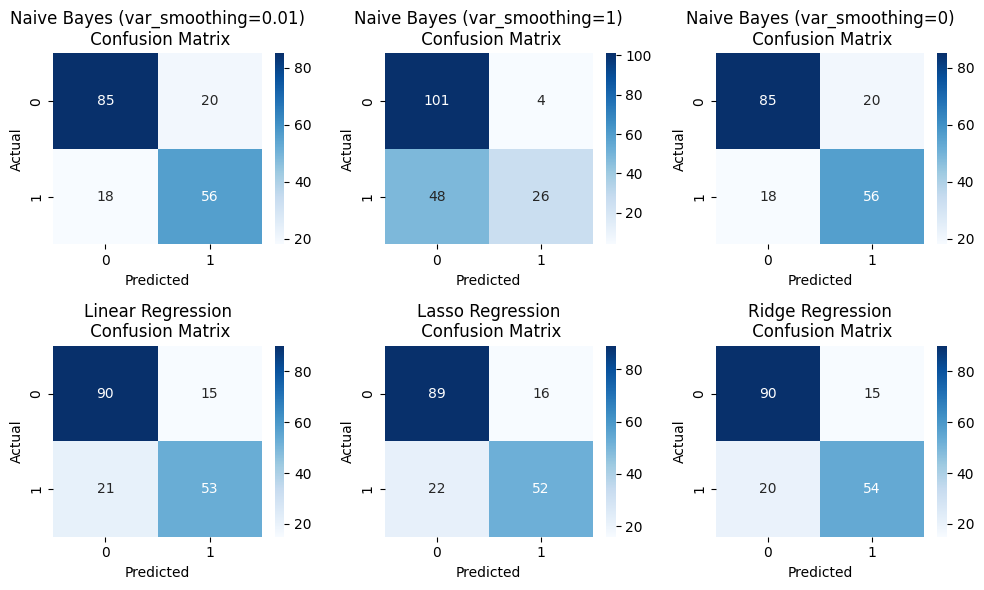

In [11]:
# Visualize all models confusion matrices

models = ['Naive Bayes (var_smoothing=0.01)', 'Naive Bayes (var_smoothing=1)', 'Naive Bayes (var_smoothing=0)', 'Linear Regression', 'Lasso Regression', 'Ridge Regression']

conf_matrices = [
    confusion_matrix(y_test, y_pred_nb_v1),
    confusion_matrix(y_test, y_pred_nb_v2),
    confusion_matrix(y_test, y_pred_nb_v3), 
    confusion_matrix(y_test, y_pred_lr), 
    confusion_matrix(y_test, y_pred_lasso_class),
    confusion_matrix(y_test, y_pred_ridge_class)
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, model_name, conf_matrix in zip(axes.flatten(), models, conf_matrices):
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{model_name}\n Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

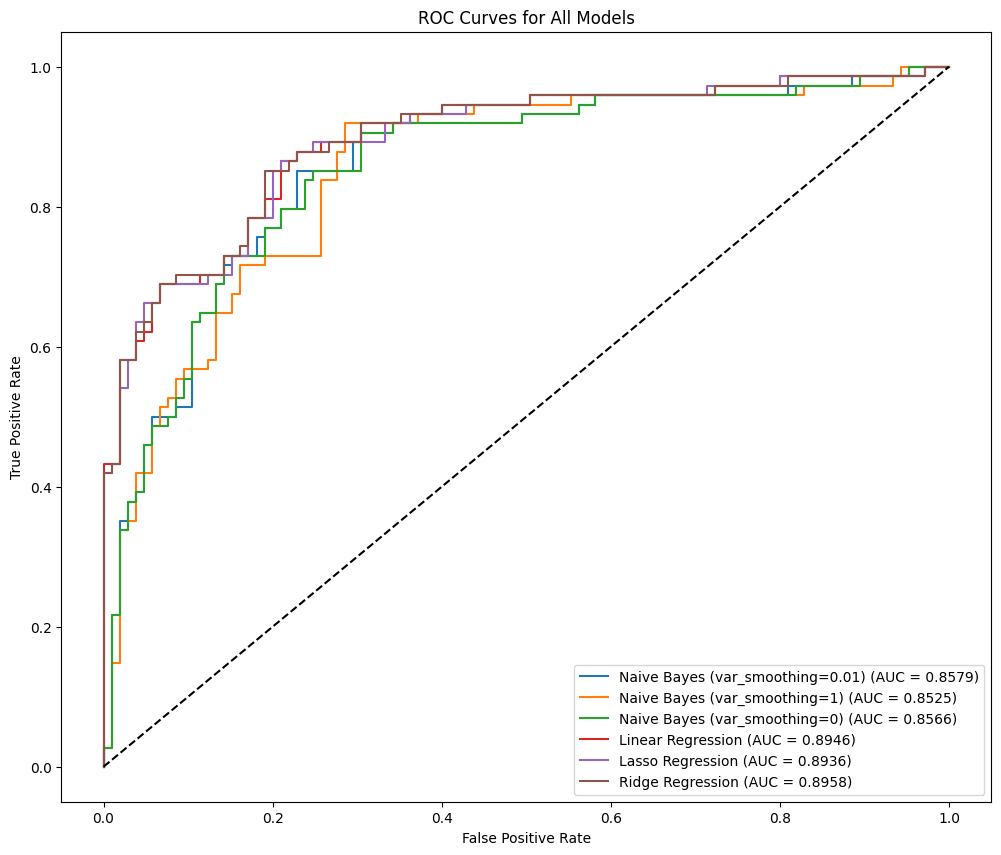

In [12]:
# Visualize all models AUROC

fitted_models = [model_nb_v1, model_nb_v2, model_nb_v3, model_lr, lasso_model, ridge_model]
models = ['Naive Bayes (var_smoothing=0.01)', 'Naive Bayes (var_smoothing=1)', 'Naive Bayes (var_smoothing=0)', 'Linear Regression', 'Lasso Regression', 'Ridge Regression']

y_preds = [
    m.predict_proba(X_test)[:, 1] if hasattr(m, 'predict_proba') 
    else m.predict(X_test) 
    for m in fitted_models
]

plt.figure(figsize=(12, 10))
for model_name, y_pred in zip(models, y_preds):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.show()

In [13]:
# visualize the classification reports for all models

fitted_models = [model_nb_v1, model_nb_v2, model_nb_v3, model_lr, lasso_model, ridge_model]
models = ['Naive Bayes (var_smoothing=0.01)', 'Naive Bayes (var_smoothing=1)', 'Naive Bayes (var_smoothing=0)', 'Linear Regression', 'Lasso Regression', 'Ridge Regression']

y_preds = [
    m.predict_proba(X_test)[:, 1] if hasattr(m, 'predict_proba') 
    else m.predict(X_test) 
    for m in fitted_models
]

for model_name, y_pred in zip(models, y_preds):
    y_pred_class = (y_pred >= 0.5).astype(int)
    print(f'Classification Report for {model_name}:\n')
    print(classification_report(y_test, y_pred_class))

Classification Report for Naive Bayes (var_smoothing=0.01):

              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82       105
         1.0       0.74      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Classification Report for Naive Bayes (var_smoothing=1):

              precision    recall  f1-score   support

         0.0       0.68      0.96      0.80       105
         1.0       0.87      0.35      0.50        74

    accuracy                           0.71       179
   macro avg       0.77      0.66      0.65       179
weighted avg       0.76      0.71      0.67       179

Classification Report for Naive Bayes (var_smoothing=0):

              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82       105
         1.0       0.74      0.76      0.75        74

    a